## Установка и импорт нужных библиотек

In [2]:
from tqdm.notebook import tqdm
import pandas as pd
from typing import Optional, List, Tuple
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# !pip install -U langchain
# !pip install langchain-text-splitters
# !pip install -U sentence-transformers
# !pip install -U langchain-community
# !pip install -U langchain-huggingface  
# pip install faiss-cpu

## Датасет

In [3]:
df = pd.read_csv("websites_updated.csv", encoding="utf-8")
df.head(3)

,web_id,url,kind,title,text
0,1,https://alfabank.ru/,html,"Альфа-Банк - кредитные и дебетовые карты, кред...",Рассчитайте выгоду\nРасчёт калькулятора предва...
1,2,https://alfabank.ru/a-club/,html,А-Клуб. Деньги имеют значение,Брокерские услуги\nОткрытие брокерского счёта ...
2,3,https://alfabank.ru/a-club/ultimate/,html,А-Клуб. Деньги имеют значение,Хотите получить больше информации?\nПозвоните ...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   web_id  1938 non-null   int64 
 1   url     1938 non-null   object
 2   kind    1937 non-null   object
 3   title   1937 non-null   object
 4   text    1937 non-null   object
dtypes: int64(1), object(4)
memory usage: 75.8+ KB


In [5]:
df.isna().sum() # пропусков мало

web_id    0
url       0
kind      1
title     1
text      1
dtype: int64

In [6]:
df.nunique()

web_id    1938
url       1921
kind         2
title     1588
text      1921
dtype: int64

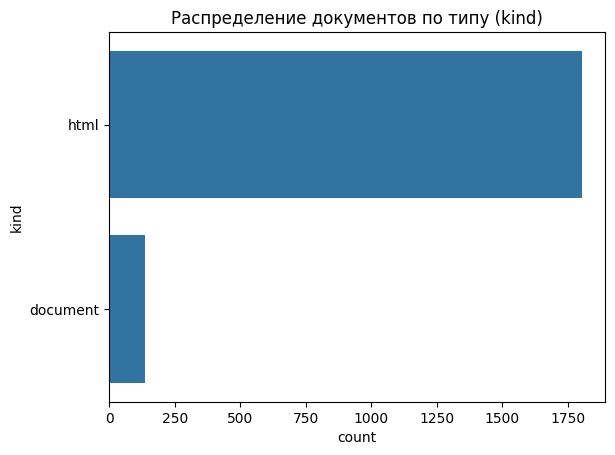

In [7]:
sns.countplot(y="kind", data=df, order=df["kind"].value_counts().index)
plt.title("Распределение документов по типу (kind)")
plt.show()

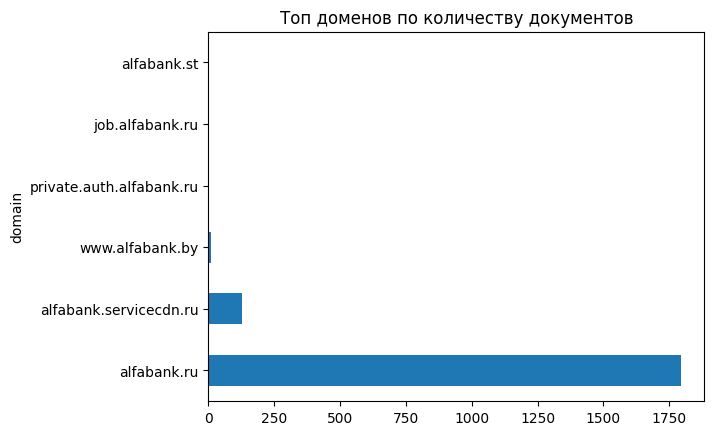

In [8]:
df["domain"] = df["url"].str.extract(r"https?://([^/]+)/")
df["domain"].value_counts().plot(kind="barh")
plt.title("Топ доменов по количеству документов")
plt.show()

In [9]:
# Частотность повторяющихся заголовков (кандидаты на дубликаты)
dup_titles = df["title"].value_counts()
pd.DataFrame(dup_titles[dup_titles > 1])

,count
title,
О внесении изменений в Договор о комплексном банковском обслуживании,126
О внесении изменений в Договор о комплексном банковском обслуживании,67
Об изменениях в Тарифы по Договору о комплексном банковском обслуживании физических лиц,32
Без названия,14
Об изменениях в Тарифы по Договору о комплексном банковском обслуживании физических лиц,13
...,...
Новая скорость бизнеса,2
Альфа-Банк: страница не найдена,2
Не могу забрать карту в назначенное время или назначенном месте. Что делать?,2


In [10]:
# Частота стоп-слов или HTML-тегов
df["text"].str.contains(r"<[^>]+>").mean()

# Очистка не нужна

np.float64(0.002581311306143521)

In [11]:
df["text_len_words"] = df["text"].astype(str).str.split().str.len() # кол-во слов в каждой строке

print("Средняя длина текста (в словах):", df["text_len_words"].mean())
print("Максимальная длина:", df["text_len_words"].max())
print("Минимальная длина:", df["text_len_words"].min())

Средняя длина текста (в словах): 863.8457172342621
Максимальная длина: 174641
Минимальная длина: 0


In [12]:
# Одна строка с пропусками (удаляем)
missing_rows = df[df.isna().any(axis=1)]
print("Количество строк с пропусками:", len(missing_rows))
missing_rows.head()

Количество строк с пропусками: 1


,web_id,url,kind,title,text,domain,text_len_words
1937,1938,https://job.alfabank.ru/vacancies/moskva,NaN,NaN,NaN,job.alfabank.ru,1


In [13]:
# Две строки с путым тексом 
df[df["text"].str.strip() == ""]

,web_id,url,kind,title,text,domain,text_len_words
1706,1707,https://alfabank.servicecdn.ru/site-upload/c7/...,document,Private_s_1082025.pdf,,alfabank.servicecdn.ru,0
1877,1878,https://www.alfabank.by/upload/docs/bank/liche...,document,lichenzia.pdf,,www.alfabank.by,0


In [14]:
# удаляю строки, где нет текста или он пустой
df = df[df["text"].notna() & (df["text"].str.strip() != "")]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1935 entries, 0 to 1936
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   web_id          1935 non-null   int64 
 1   url             1935 non-null   object
 2   kind            1935 non-null   object
 3   title           1935 non-null   object
 4   text            1935 non-null   object
 5   domain          1935 non-null   object
 6   text_len_words  1935 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 120.9+ KB


In [15]:
print("Общая статистика по длине (в словах):")
df["text_len_words"].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])

Общая статистика по длине (в словах):


count      1935.000000
mean        865.184496
std        5739.141822
min           1.000000
10%          33.000000
25%          77.500000
50%         300.000000
75%         999.500000
90%        1409.200000
95%        1831.300000
99%        6225.400000
max      174641.000000
Name: text_len_words, dtype: float64

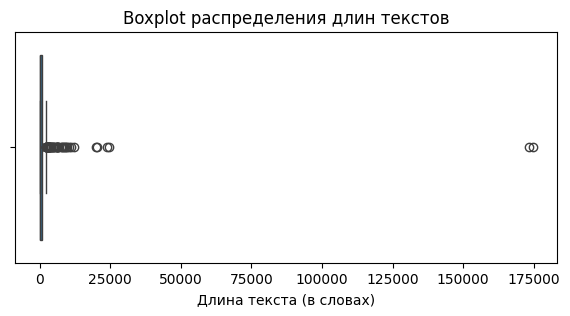

In [16]:
plt.figure(figsize=(7,3))
sns.boxplot(x=df["text_len_words"])
plt.xlabel("Длина текста (в словах)")
plt.title("Boxplot распределения длин текстов")
plt.show()

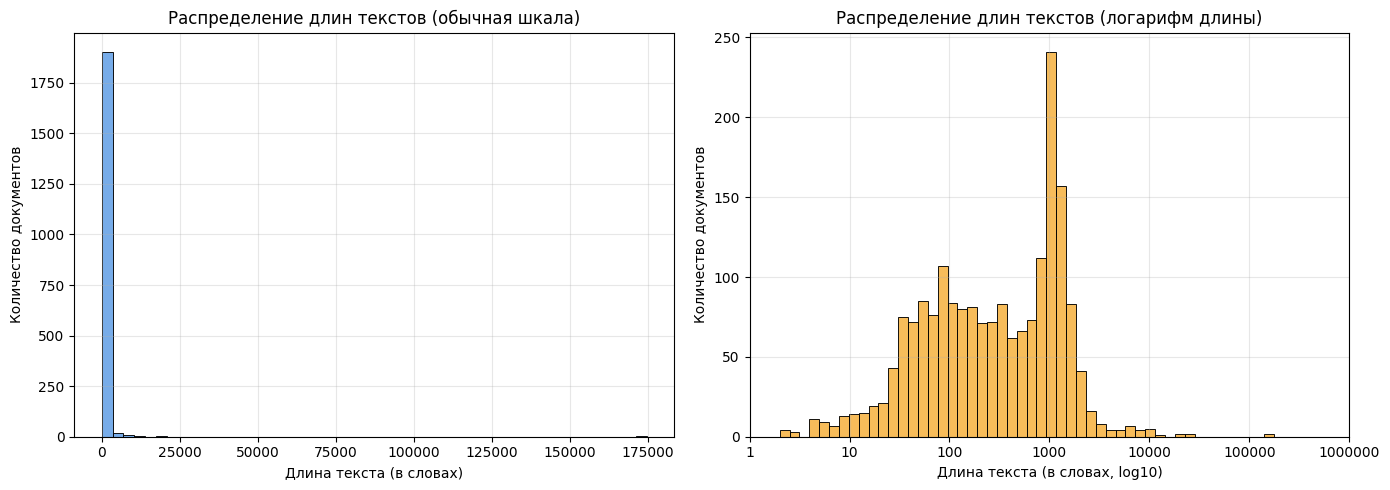

In [17]:
df["log_len_words"] = np.log10(df["text_len_words"] + 1)

plt.figure(figsize=(14, 5))

# показывает реальное распределение, но длинные тексты почти не видны (то есть большинство страниц короткие)
plt.subplot(1, 2, 1)
sns.histplot(df["text_len_words"], bins=50, color="#4a90e2")
plt.xlabel("Длина текста (в словах)")
plt.ylabel("Количество документов")
plt.title("Распределение длин текстов (обычная шкала)")
plt.grid(alpha=0.3)

# логарифмированное распределение сжимает хвосты, теперь ты видно и короткие, и длинные тексты на одном графике
plt.subplot(1, 2, 2)
sns.histplot(df["log_len_words"], bins=50, color="#f5a623")

max_log = np.ceil(df["log_len_words"].max())
plt.xticks(
    ticks=np.arange(0, max_log + 1),
    labels=[f"{int(10**i)}" for i in range(int(max_log) + 1)]
)
plt.xlabel("Длина текста (в словах, log10)")
plt.ylabel("Количество документов")
plt.title("Распределение длин текстов (логарифм длины)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**ВЫВОД**
1. Корпус из 1935 текстов имеет высокую вариативность длин
2. Медианная длина составляет ~300 слов, при этом 95 % текстов короче 2000 слов.
3. Около 1 % документов превышают 10 000 слов — они искажают распределение.
4. Имеются дубликаты текстов.
5. Для большинства текстов оптимальный размер чанка — 1000 символов (≈200 слов) с перекрытием 100 символов.(совет гпт)
6. Мне кажется, можно оставить изначальный датасет 

**ВОПРОСЫ:**
1. Аномально длинные документы (которых очень мало) оставляем? - наверное надо оставить, все равно будем делить на чанки.
2. Что делаем с пропусками и путыми значениями - при удалении лишаемся всего 3ех строк (с 1938 до 1935). Думаю, надо удалять. (в одной строке NaN, в двух - пустой текст "").
3. Дубликаты текста есть, но одни тексты относятся к разным url. Если оставить то retriever будет переоценивать такие документы (несколько идентичных чанков усилят их веса в векторном пространстве). Можно не трогать, удалить все дубликаты текста (df.drop_duplicates(subset=["text"]))- останется 1919 , оставить один экземпляр каждого URL (df.drop_duplicates(subset=["url"])) - останется 1918.

In [18]:
df.nunique()

web_id            1935
url               1918
kind                 2
title             1586
text              1919
domain               6
text_len_words     959
log_len_words      959
dtype: int64

In [19]:
df = df.drop_duplicates(subset=["text"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1919 entries, 0 to 1936
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   web_id          1919 non-null   int64  
 1   url             1919 non-null   object 
 2   kind            1919 non-null   object 
 3   title           1919 non-null   object 
 4   text            1919 non-null   object 
 5   domain          1919 non-null   object 
 6   text_len_words  1919 non-null   int64  
 7   log_len_words   1919 non-null   float64
dtypes: float64(1), int64(2), object(5)
memory usage: 134.9+ KB


In [20]:
#df.to_csv("Websites_clean.csv", index=False, encoding="utf-8") # сохранение очищенного файла 

## Разбиение документа на чанки

In [21]:
df.shape 

(1919, 8)

In [22]:
# Прежде преобразую LangChain Document
from langchain_core.documents import Document

RAW_KNOWLEDGE_BASE = [
    Document(
        page_content=row["text"],
        metadata={
            "url": row["url"],
            "title": row["title"],
            "kind": row["kind"],
            "web_id": row["web_id"]
        }
    )
    for _, row in df.iterrows()
]

In [28]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


# Мы используем иерархический список разделителей, специально предназначенных для разделения документов Markdown
# Этот список взят из класса MarkdownTextSplitter в LangChain

MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    " ",
    "",
]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=384,  # Максимальное количество символов в чанке
    chunk_overlap=64,  # Количество символов, которые будут перекрываться между чанками
    add_start_index=True,  # Если "True", то включает начальный индекс чанка в метаданные
    strip_whitespace=True,  # Если значение "True", то пробелы удаляются из начала и конца каждого документа
    separators=MARKDOWN_SEPARATORS,
)

docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
    docs_processed += text_splitter.split_documents([doc])

Model's maximum sequence length: 512


  0%|          | 0/45646 [00:00<?, ?it/s]

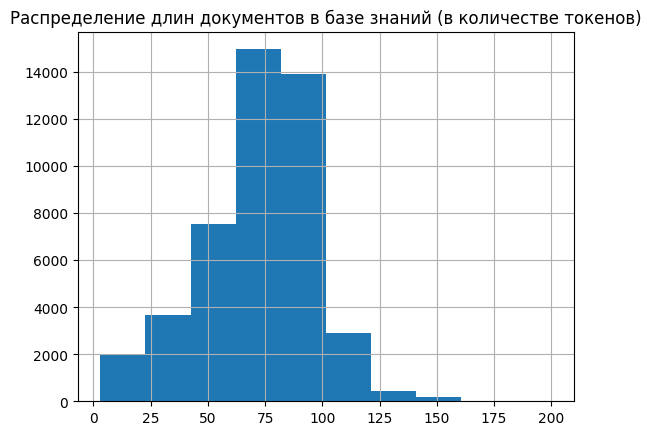

In [29]:
from sentence_transformers import SentenceTransformer

# Чтобы получить значение max sequence_length, мы запросим базовый объект `SentenceTransformer`, используемый в RecursiveCharacterTextSplitter
print(f"Model's maximum sequence length: {SentenceTransformer('intfloat/multilingual-e5-large').max_seq_length}")

from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-large")
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]

# Построим график распределения длин документов, подсчитываемых как количество токенов
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()

In [ ]:
# from langchain_text_splitters import RecursiveCharacterTextSplitter
# from langchain_core.documents import Document
# from transformers import AutoTokenizer

# EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-large"


# def split_documents(
#     chunk_size: int,
#     knowledge_base: List[Document],
#     tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
# ) -> List[Document]:
#     """
#     Разобьём документы на блоки максимального размера `chunk_size`
#     и вернём список документов с учётом префикса для GTE (`passage: `).
#     """
#     text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
#         AutoTokenizer.from_pretrained(tokenizer_name),
#         chunk_size=chunk_size,
#         chunk_overlap=int(chunk_size / 10),
#         add_start_index=True,
#         strip_whitespace=True,
#         separators=MARKDOWN_SEPARATORS,
#     )

#     docs_processed: List[Document] = []

#     for doc in knowledge_base:
#         chunks = text_splitter.split_documents([doc])

#         # добавляем префикс "passage: " для каждого чанка
#         for ch in chunks:
#             content = ch.page_content.strip()
#             # на случай, если функцию вызовут повторно — не дублируем префикс
#             if not content.lower().startswith("passage:"):
#                 ch.page_content = "passage: " + content

#         docs_processed.extend(chunks)

#     # Удалим дубли уже с учётом префикса
#     unique_texts = {}
#     docs_processed_unique = []
#     for doc in docs_processed:
#         if doc.page_content not in unique_texts:
#             unique_texts[doc.page_content] = True
#             docs_processed_unique.append(doc)

#     return docs_processed_unique


# docs_processed = split_documents(
#     512,  # Выбираем размер чанка, соответствующий модели
#     RAW_KNOWLEDGE_BASE,
#     tokenizer_name=EMBEDDING_MODEL_NAME,
# )


  0%|          | 0/45646 [00:00<?, ?it/s]

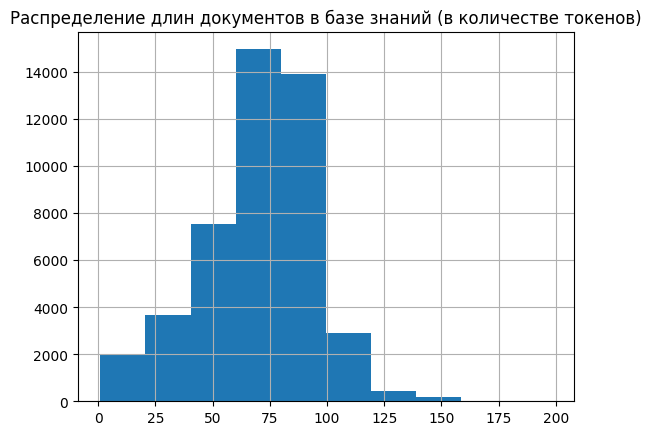

In [32]:
from transformers import AutoTokenizer
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-large"

# tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
lengths = [
    len(tokenizer.encode(doc.page_content, add_special_tokens=False))
    for doc in tqdm(docs_processed)
]
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()


## Процесс извлечения информации

In [33]:
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain_huggingface import HuggingFaceEmbeddings
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},  # `True` для косинусного сходства
)

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [36]:
KNOWLEDGE_VECTOR_DATABASE.save_local("faiss_index_1")

In [37]:
# можно проврерить визуализацией PCA 

In [38]:
# from langchain_community.vectorstores import FAISS
# db = FAISS.load_local("faiss_index", embedding_model, allow_dangerous_deserialization=True)

In [39]:
from langchain_community.vectorstores import FAISS
retriever = FAISS.load_local(
    "faiss_index_1", embedding_model, allow_dangerous_deserialization=True
).as_retriever(search_kwargs={"k": 5})

In [40]:
# проверка 
query = "Здравствуйте . Могу ли я оформить кредит, чтоб деньги сразу поступили на карту в кабинет?"

In [41]:
# results = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score(query, k=5)

# for (doc, score) in docs_processed:
#     print(round(float(score), 4), d.metadata.get("title"))
#     print(f"URL: {doc.metadata.get('url', '—')}")
#     print(f"Фрагмент: {doc.page_content[:250]}...")

print(f"\nStarting retrieval for {query=}...")
retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=query, k=5)
print("\n==================================Top document==================================")
print(retrieved_docs[0].page_content)
print("==================================Metadata==================================")
print(retrieved_docs[0].metadata)


Starting retrieval for query='Здравствуйте . Могу ли я оформить кредит, чтоб деньги сразу поступили на карту в кабинет?'...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 


==================================Top document==================================
до 14:00, кредитку привезут в этот же день. Вы можете сразу воспользоваться деньгами.
==================================Metadata==================================
{'url': 'https://alfabank.ru/get-money/credit-cards/zaym-na-kartu/?oirutpspid=1755624904390_f4341ce5b8491fece1822deebd2f7b8d_p7wx4d8psjcwikfp&oirutpspsc=1755625355776_4a348b4beb7244e5a3a218dd6d9e8c84_ux4GUPXCZyHjlxm8UvGZ0LV9VPUWGWRV6syNuJH.kKcZ&oirutpspjs=1755625355776_345962fb_0135006b_90d569d456fc8873f7112ab6373b158a_44v3xlqCHm8yCNW09QEu4ACZfmPnT5pJOWWUwXVYWorr1mc2l%2F8eexoVnDlAyED13JRNLtLKxuaojVye0uiVUrfe2mj%2BlDBkBY6ayi7DVtanvwthqPAcDKUsgMBZwW7e0vpWAq7zj08QR1Oid0y46a0QBHKmjh96a0dG42J%2FZITI0Bk9odnlABwiu%2FsSTwdgmoNqaIxUAPAEfck8TdVnh5buWluPR%2FYDQh3kxB0VfZjU7oYl%2B4WIbSCkBIT%2FUby%2FaXD1tDAIiJls5tOj8ZsO3ipjFtjFSCVjreWY%2BLBOw%2FOLhage9UqXdz38yP6MNYDmoYlc76izx0WDm5pbL3dtDIDpVaJOR9q68MvTY%2B%2F3TujG3mKVBV2fXbggJHQkvQrKz2ZTw%2FYvmm0KFbm4VdnltYnw

## Сохранение ответа

In [42]:
pd.read_csv("questions_clean.csv") 

,q_id,query
0,1,Номер счета
1,2,Где узнать бик и счёт
2,3,Мне не приходят коды для подтверждения данной ...
3,4,"Оформила рассрочку ,но уведомлений никаких не ..."
4,5,"Здравствуйте, когда смогу пользоваться кредитн..."
...,...,...
6972,6973,"Здравствуйте, оплатил вчера ЖКХ а кэшбек не на..."
6973,6974,"Здравствуйте, можно ли заказать реквизиты бан..."
6974,6975,"Здравствуйте, подскажите пожалуйста где я могу..."
6975,6976,Реквизиты для оплаты номера карты


In [43]:
# def retrieve_top5_unique_ids_fast(query: str,
#                                   min_k: int = 5,
#                                   k_init: int = 10,
#                                   k_max: int = 50):
#     """
#     Быстрая версия: достаёт ближайшие документы по косинусному сходству,
#     убирает дубли web_id, при необходимости расширяет выборку до k_max.
#     """
#     # GTE/E5 префикс
#     q = f"query: {query.strip()}"

#     # 1) начальный поиск
#     results = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score(q, k=k_init)

#     # 2) соберём уникальные id
#     ids = []
#     seen = set()
#     for d, score in results:
#         wid = d.metadata.get("web_id")
#         if wid and wid not in seen:
#             seen.add(wid)
#             ids.append(int(wid))
#         if len(ids) == min_k:
#             break

#     # 3) если всё ещё меньше — расширяем поиск
#     if len(ids) < min_k and k_init < k_max:
#         results = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score(q, k=k_max)
#         for d, score in results:
#             wid = d.metadata.get("web_id")
#             if wid and wid not in seen:
#                 seen.add(wid)
#                 ids.append(int(wid))
#             if len(ids) == min_k:
#                 break

#     # 4) fallback
#     if len(ids) < min_k:
#         ids = (ids + ids)[:min_k]

#     return ids[:min_k]


In [44]:
# def retrieve_topk(query, k=5):
#     q = f"query: {query}"  # если используешь e5
#     results = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score(q, k=k)
#     ids = [int(d.metadata.get("web_id")) for d, _ in results if d.metadata.get("web_id") is not None]
#     return ids[:k]  # возвращаем список

In [45]:
# import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"


# questions = pd.read_csv("questions_clean.csv")  

# rows = []
# for r in tqdm(questions.itertuples(), total=len(questions), desc="Retrieving"):
#     ids5 = retrieve_top5_unique_ids_fast(r.query, min_k=5, k_init=10, k_max=50)
#     rows.append({"q_id": int(r.q_id), "web_list": str(ids5)})


In [46]:
# import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# questions = pd.read_csv("questions_clean.csv")  

# rows = []
# for r in tqdm(questions.itertuples(), total=len(questions), desc="Retrieving"):
#     top5_ids = retrieve_topk(r.query, k=5)
#     rows.append({"q_id": int(r.q_id), "web_ids_top5": str(top5_ids)})  # сохраняем как строку "[...]"

In [47]:
# # сохраняем в CSV
# df = pd.DataFrame(rows, columns=["q_id", "web_list"])
# df.to_csv("retrieval_results.csv", index=False, encoding="utf-8")

# print("Файл сохранён: retrieval_results.csv")

In [48]:
# df

In [49]:
# df = pd.read_csv("retrieval_results.csv")
# df

In [50]:
# df.web_list

In [51]:
print(docs_processed[1].metadata)

{'url': 'https://alfabank.ru/', 'title': 'Альфа-Банк - кредитные и дебетовые карты, кредиты наличными, автокредитование, ипотека и другие банковские услуги физическим и юридическим лицам – Альфа-Банк', 'kind': 'html', 'web_id': 1, 'start_index': 270}


In [52]:
test_q = "Как оформить ипотеку в Альфа-Банке?"
print(retrieve_topk(test_q, k=5))
print(type(retrieve_topk(test_q, k=5)))

NameError: name 'retrieve_topk' is not defined

In [ ]:
# questions = pd.read_csv("questions_clean.csv").head()

# # 1. Применяем retrieve_topk и сразу смотрим первые 5 значений
# questions["web_ids_top5"] = questions["query"].apply(retrieve_topk)

# print(questions["web_ids_top5"].head())
# print(questions["web_ids_top5"].apply(type).head())

In [54]:
import pandas as pd
from tqdm import tqdm

# 1. Загружаем вопросы
questions = pd.read_csv("questions_clean.csv")  # должно быть q_id и query

print(questions.head())
print(questions.dtypes)
# убедись, что есть колонки q_id (int/float) и query (str)

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"


# 2. Функция поиска top-k web_id
def retrieve_topk_ids(query: str, k: int = 5):
    # для E5/GTE — обязательно префикс "query: "
    q = f"query: {query.strip()}"

    results = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score(q, k=k)

    ids = []
    for d, _ in results:
        wid = d.metadata.get("web_id")
        if wid is None:
            continue
        try:
            ids.append(int(wid))
        except Exception as e:
            print("⚠️ не удалось привести web_id к int:", wid, e)
            continue

    # если ничего не нашли — вернём пустой список (а не NaN)
    return ids[:k]


# 3. Прогоняем по всем вопросам и собираем результат
rows = []
for r in tqdm(questions.itertuples(), total=len(questions), desc="Retrieving"):
    ids = retrieve_topk_ids(r.query, k=5)   # список типа [1, 120, 57, 803, 19]
    rows.append({
        "q_id": int(r.q_id),
        # приводим список к строке, чтобы в CSV не превратилось в NaN
        "web_ids_top5": str(ids),
    })
3
df_out = pd.DataFrame(rows, columns=["q_id", "web_ids_top5"])

print(df_out.head())
print(df_out.dtypes)

# 4. Сохраняем в CSV
df_out.to_csv("retrieval_results.csv", index=False, encoding="utf-8")
print("✅ Готово: сохранён retrieval_results.csv")

   q_id                                              query
0     1                                        Номер счета
1     2                              Где узнать бик и счёт
2     3  Мне не приходят коды для подтверждения данной ...
3     4  Оформила рассрочку ,но уведомлений никаких не ...
4     5  Здравствуйте, когда смогу пользоваться кредитн...
q_id      int64
query    object
dtype: object


Retrieving: 100%|████████████████████████| 6977/6977 [15:49:26<00:00,  8.16s/it]

   q_id                    web_ids_top5
0     1  [1795, 1795, 1157, 1795, 1795]
1     2      [372, 319, 1113, 866, 374]
2     3    [1726, 116, 1752, 1032, 116]
3     4   [1704, 1705, 1759, 322, 1038]
4     5      [776, 1586, 124, 159, 937]
q_id             int64
web_ids_top5    object
dtype: object
✅ Готово: сохранён retrieval_results.csv


In [56]:
df_out.to_csv("otv.csv", index=False, encoding="utf-8")

In [57]:
pd.read_csv("otv.csv")

,q_id,web_ids_top5
0,1,"[1795, 1795, 1157, 1795, 1795]"
1,2,"[372, 319, 1113, 866, 374]"
2,3,"[1726, 116, 1752, 1032, 116]"
3,4,"[1704, 1705, 1759, 322, 1038]"
4,5,"[776, 1586, 124, 159, 937]"
...,...,...
6972,6973,"[1902, 60, 1516, 420, 1552]"
6973,6974,"[368, 1157, 1705, 751, 715]"
6974,6975,"[1014, 1014, 1704, 1705, 1014]"
6975,6976,"[1774, 1784, 108, 1704, 1705]"
